### Load Dependencies and Data

In [2]:
%load_ext autoreload
%autoreload 2

In [49]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import yaml
import numpy as np


Add src folder to sys.path so Python can find your package

In [50]:
ROOT = Path.cwd().parent     # project root directory when working interactively
sys.path.append(str(ROOT / "src"))

Import the root folder of the project : house_prices_tensorflow

In [51]:
from pkg_house_prices.utils.project_root import PROJECT_ROOT

Import the data

In [52]:
from pkg_house_prices.data.data_loader import train, test

### Data Exploration - Data types and missing values

In [53]:
# Determine the data types of each column in the training data
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   string 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   string 
 6   Alley          91 non-null     string 
 7   LotShape       1460 non-null   string 
 8   LandContour    1460 non-null   string 
 9   Utilities      1460 non-null   string 
 10  LotConfig      1460 non-null   string 
 11  LandSlope      1460 non-null   string 
 12  Neighborhood   1460 non-null   string 
 13  Condition1     1460 non-null   string 
 14  Condition2     1460 non-null   string 
 15  BldgType       1460 non-null   string 
 16  HouseStyle     1460 non-null   string 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [54]:
# Return columns with object data type
object_cols = train.select_dtypes(include=['object']).columns
print("\nColumns with object data type:")
print(object_cols)
# Display first few entries of these object columns
print("\nFirst few entries of object columns:")
print(train[object_cols].head())



Columns with object data type:
Index([], dtype='object')

First few entries of object columns:
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


In [55]:
# Convert object data types into string data types for easier handling
for col in object_cols:
    train[col] = train[col].astype('string')
    test[col] = test[col].astype('string')

In [56]:
# Count the number of missing values in each column and print the result
missing_counts = train.isnull().sum()
print("\nMissing values in each column of the training data:")
print(missing_counts[missing_counts > 0])
print("\nTotal number of columns with missing values is", len(missing_counts[missing_counts > 0]), " out of ", len(train.columns),".")


Missing values in each column of the training data:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Total number of columns with missing values is 19  out of  81 .


##### Drop Missing Values and Save New Data

In [57]:
# Drop the columns with missing values for now
train = train.drop(columns=missing_counts[missing_counts > 0].index)
test = test.drop(columns=missing_counts[missing_counts > 0].index)
print("\nAfter dropping, the training data now has columns:")
print(train.info())

# save cleaned datasets
train.to_csv(PROJECT_ROOT / "data/processed/train_cleaned.csv", index=False)
test.to_csv(PROJECT_ROOT / "data/processed/test_cleaned.csv", index=False)
 



After dropping, the training data now has columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Id             1460 non-null   int64 
 1   MSSubClass     1460 non-null   int64 
 2   MSZoning       1460 non-null   string
 3   LotArea        1460 non-null   int64 
 4   Street         1460 non-null   string
 5   LotShape       1460 non-null   string
 6   LandContour    1460 non-null   string
 7   Utilities      1460 non-null   string
 8   LotConfig      1460 non-null   string
 9   LandSlope      1460 non-null   string
 10  Neighborhood   1460 non-null   string
 11  Condition1     1460 non-null   string
 12  Condition2     1460 non-null   string
 13  BldgType       1460 non-null   string
 14  HouseStyle     1460 non-null   string
 15  OverallQual    1460 non-null   int64 
 16  OverallCond    1460 non-null   int64 
 17  YearBuilt      1460

Summary: 
1. Columns with object datatypes were transformed to string. 
2. All columns with missing values are dropped since they only cover less than 25% of the actual number of variables. It is assumed that the remaining variables are sufficent to predict the house prices. 

### Plot the Data

(array([ 11.,  38.,  99., 232., 273., 218., 176., 104.,  93.,  58.,  42.,
         35.,  24.,  10.,  17.,   8.,   7.,   4.,   2.,   1.,   1.,   2.,
          1.,   0.,   2.,   0.,   0.,   0.,   0.,   2.]),
 array([ 34900.        ,  58903.33333333,  82906.66666667, 106910.        ,
        130913.33333333, 154916.66666667, 178920.        , 202923.33333333,
        226926.66666667, 250930.        , 274933.33333333, 298936.66666667,
        322940.        , 346943.33333333, 370946.66666667, 394950.        ,
        418953.33333333, 442956.66666667, 466960.        , 490963.33333333,
        514966.66666667, 538970.        , 562973.33333333, 586976.66666667,
        610980.        , 634983.33333333, 658986.66666667, 682990.        ,
        706993.33333333, 730996.66666667, 755000.        ]),
 <BarContainer object of 30 artists>)

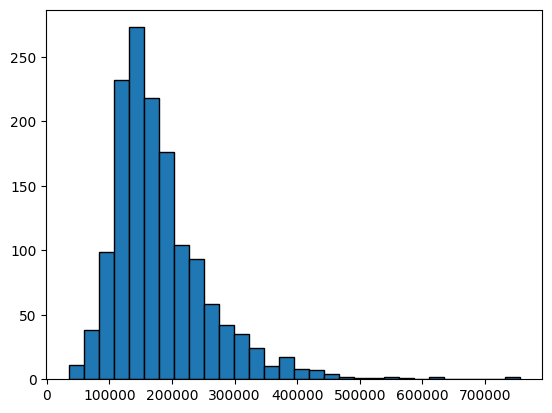

In [12]:
# Plot the distribution of the target variable 'SalePrice'
plt.hist(train['SalePrice'], bins=30, edgecolor='black')

(array([  3.,   2.,   0.,   2.,   3.,   7.,   5.,  10.,  39.,  35.,  49.,
        100., 138., 186., 146., 156., 142., 102., 100.,  68.,  52.,  44.,
         22.,  24.,  12.,   4.,   3.,   3.,   1.,   2.]),
 array([10.46027076, 10.56274421, 10.66521767, 10.76769112, 10.87016457,
        10.97263803, 11.07511148, 11.17758493, 11.28005839, 11.38253184,
        11.48500529, 11.58747874, 11.6899522 , 11.79242565, 11.8948991 ,
        11.99737256, 12.09984601, 12.20231946, 12.30479292, 12.40726637,
        12.50973982, 12.61221328, 12.71468673, 12.81716018, 12.91963363,
        13.02210709, 13.12458054, 13.22705399, 13.32952745, 13.4320009 ,
        13.53447435]),
 <BarContainer object of 30 artists>)

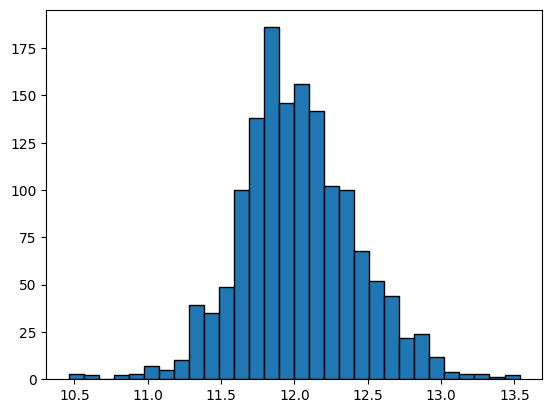

In [13]:
# From the plot above, the house price data appears to be right-skewed. A log transformation can help normalize the distribution.
plt.hist(np.log1p(train['SalePrice']), bins=30, edgecolor='black')


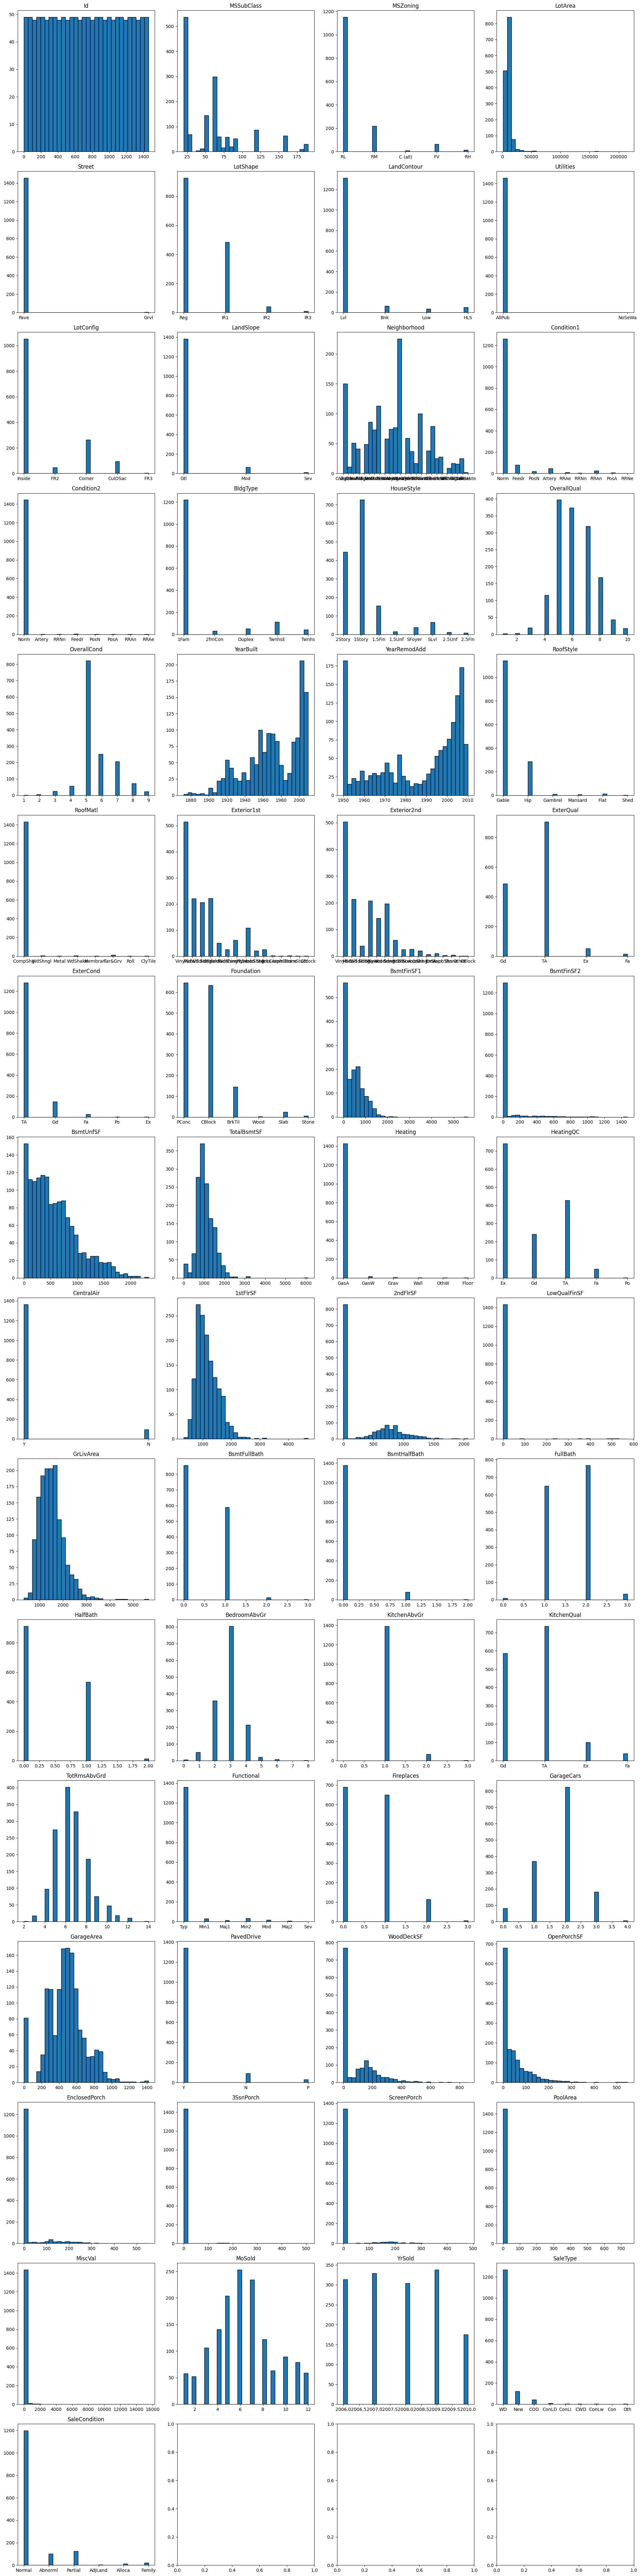

In [26]:
# Plot the histogram of explanatory variables in n by 4 grid of subplots
num_cols = len(train.columns) - 1  # Exclude target variable
n_rows = (num_cols + 3) // 4  # Calculate number of rows
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows))

for i, col in enumerate(train.columns):
    if col == 'SalePrice':
        continue  # Skip the target variable
    ax = axes[i // 4, i % 4]
    ax.hist(train[col].dropna(), bins=30, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()



In [38]:
# Identify variables with element having count more than 1400 (95.9%)
for col in train.columns:
    value_counts = train[col].value_counts()
    high_count_values = value_counts[value_counts > 1400]
    if not high_count_values.empty:
        print(f"\nColumn '{col}' has the following values with counts greater than 1400:")
        print(high_count_values) 


Column 'Street' has the following values with counts greater than 1400:
Street
Pave    1454
Name: count, dtype: Int64

Column 'Utilities' has the following values with counts greater than 1400:
Utilities
AllPub    1459
Name: count, dtype: Int64

Column 'Condition2' has the following values with counts greater than 1400:
Condition2
Norm    1445
Name: count, dtype: Int64

Column 'RoofMatl' has the following values with counts greater than 1400:
RoofMatl
CompShg    1434
Name: count, dtype: Int64

Column 'Heating' has the following values with counts greater than 1400:
Heating
GasA    1428
Name: count, dtype: Int64

Column 'LowQualFinSF' has the following values with counts greater than 1400:
LowQualFinSF
0    1434
Name: count, dtype: int64

Column '3SsnPorch' has the following values with counts greater than 1400:
3SsnPorch
0    1436
Name: count, dtype: int64

Column 'PoolArea' has the following values with counts greater than 1400:
PoolArea
0    1453
Name: count, dtype: int64

Column 'M

In [15]:
# return the variables with discrete numerical values that may be categorical
discrete_numerical_cols = [col for col in train.select_dtypes(include=['int64', 'float64']).columns if train[col].nunique() < 15]
print("\nDiscrete numerical columns that may be categorical:")
# print in column format
for x in discrete_numerical_cols:
    print(x)



Discrete numerical columns that may be categorical:
OverallQual
OverallCond
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
TotRmsAbvGrd
Fireplaces
GarageCars
PoolArea
MoSold
YrSold


In [16]:
# Print the values of LowQualFinSF to see why it has so many zeros
print("\nValues of LowQualFinSF:")
print(train['LowQualFinSF'].value_counts())
# It appears that most houses have no low quality finished square feet, leading to many zeros in this column.


Values of LowQualFinSF:
LowQualFinSF
0      1434
80        3
360       2
513       1
528       1
572       1
144       1
234       1
392       1
371       1
420       1
390       1
473       1
156       1
515       1
53        1
232       1
481       1
120       1
514       1
397       1
479       1
205       1
384       1
Name: count, dtype: int64


#### SCATTERPLOTS - NUMERICAL VARIABLES

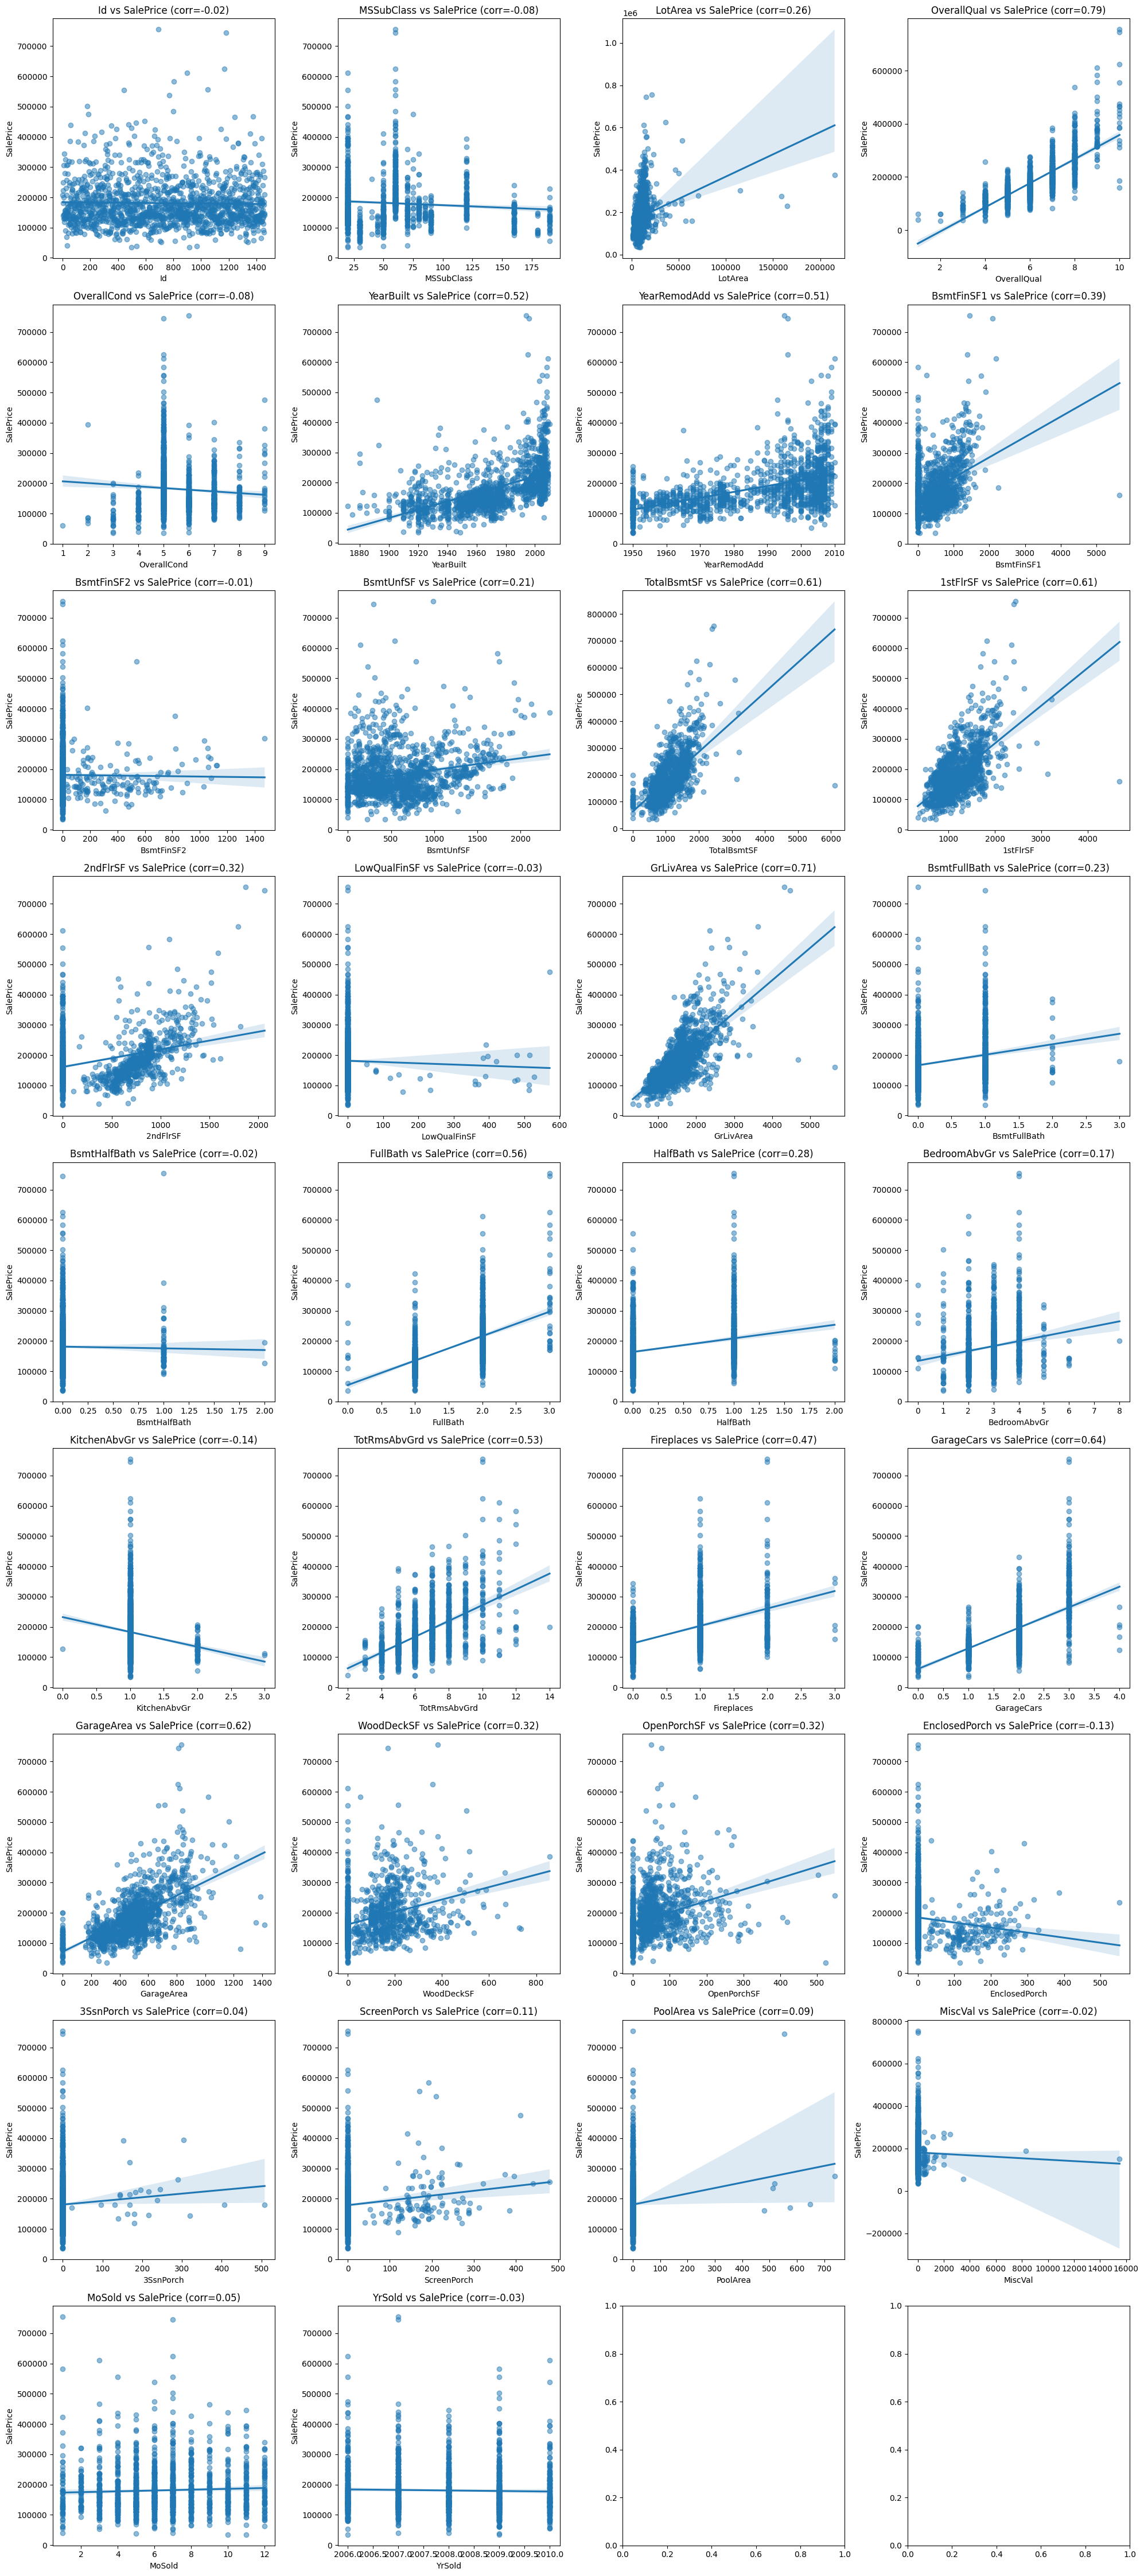

In [47]:
# Create scatter plots in n by 4 grid with regression lines and correlation for numerical variables against SalePrice
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.drop('SalePrice')
n_rows = (len(numerical_cols) + 3) // 4  # Calculate number of rows
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows))
for i, col in enumerate(numerical_cols):
    ax = axes[i // 4, i % 4]
    sns.regplot(x=train[col], y=train['SalePrice'], ax=ax, scatter_kws={'alpha':0.5})
    corr = train[col].corr(train['SalePrice'])
    ax.set_title(f"{col} vs SalePrice (corr={corr:.2f})")
plt.tight_layout()
plt.show()



#### BOXPLOTS - CATEGORICAL VARIABLES

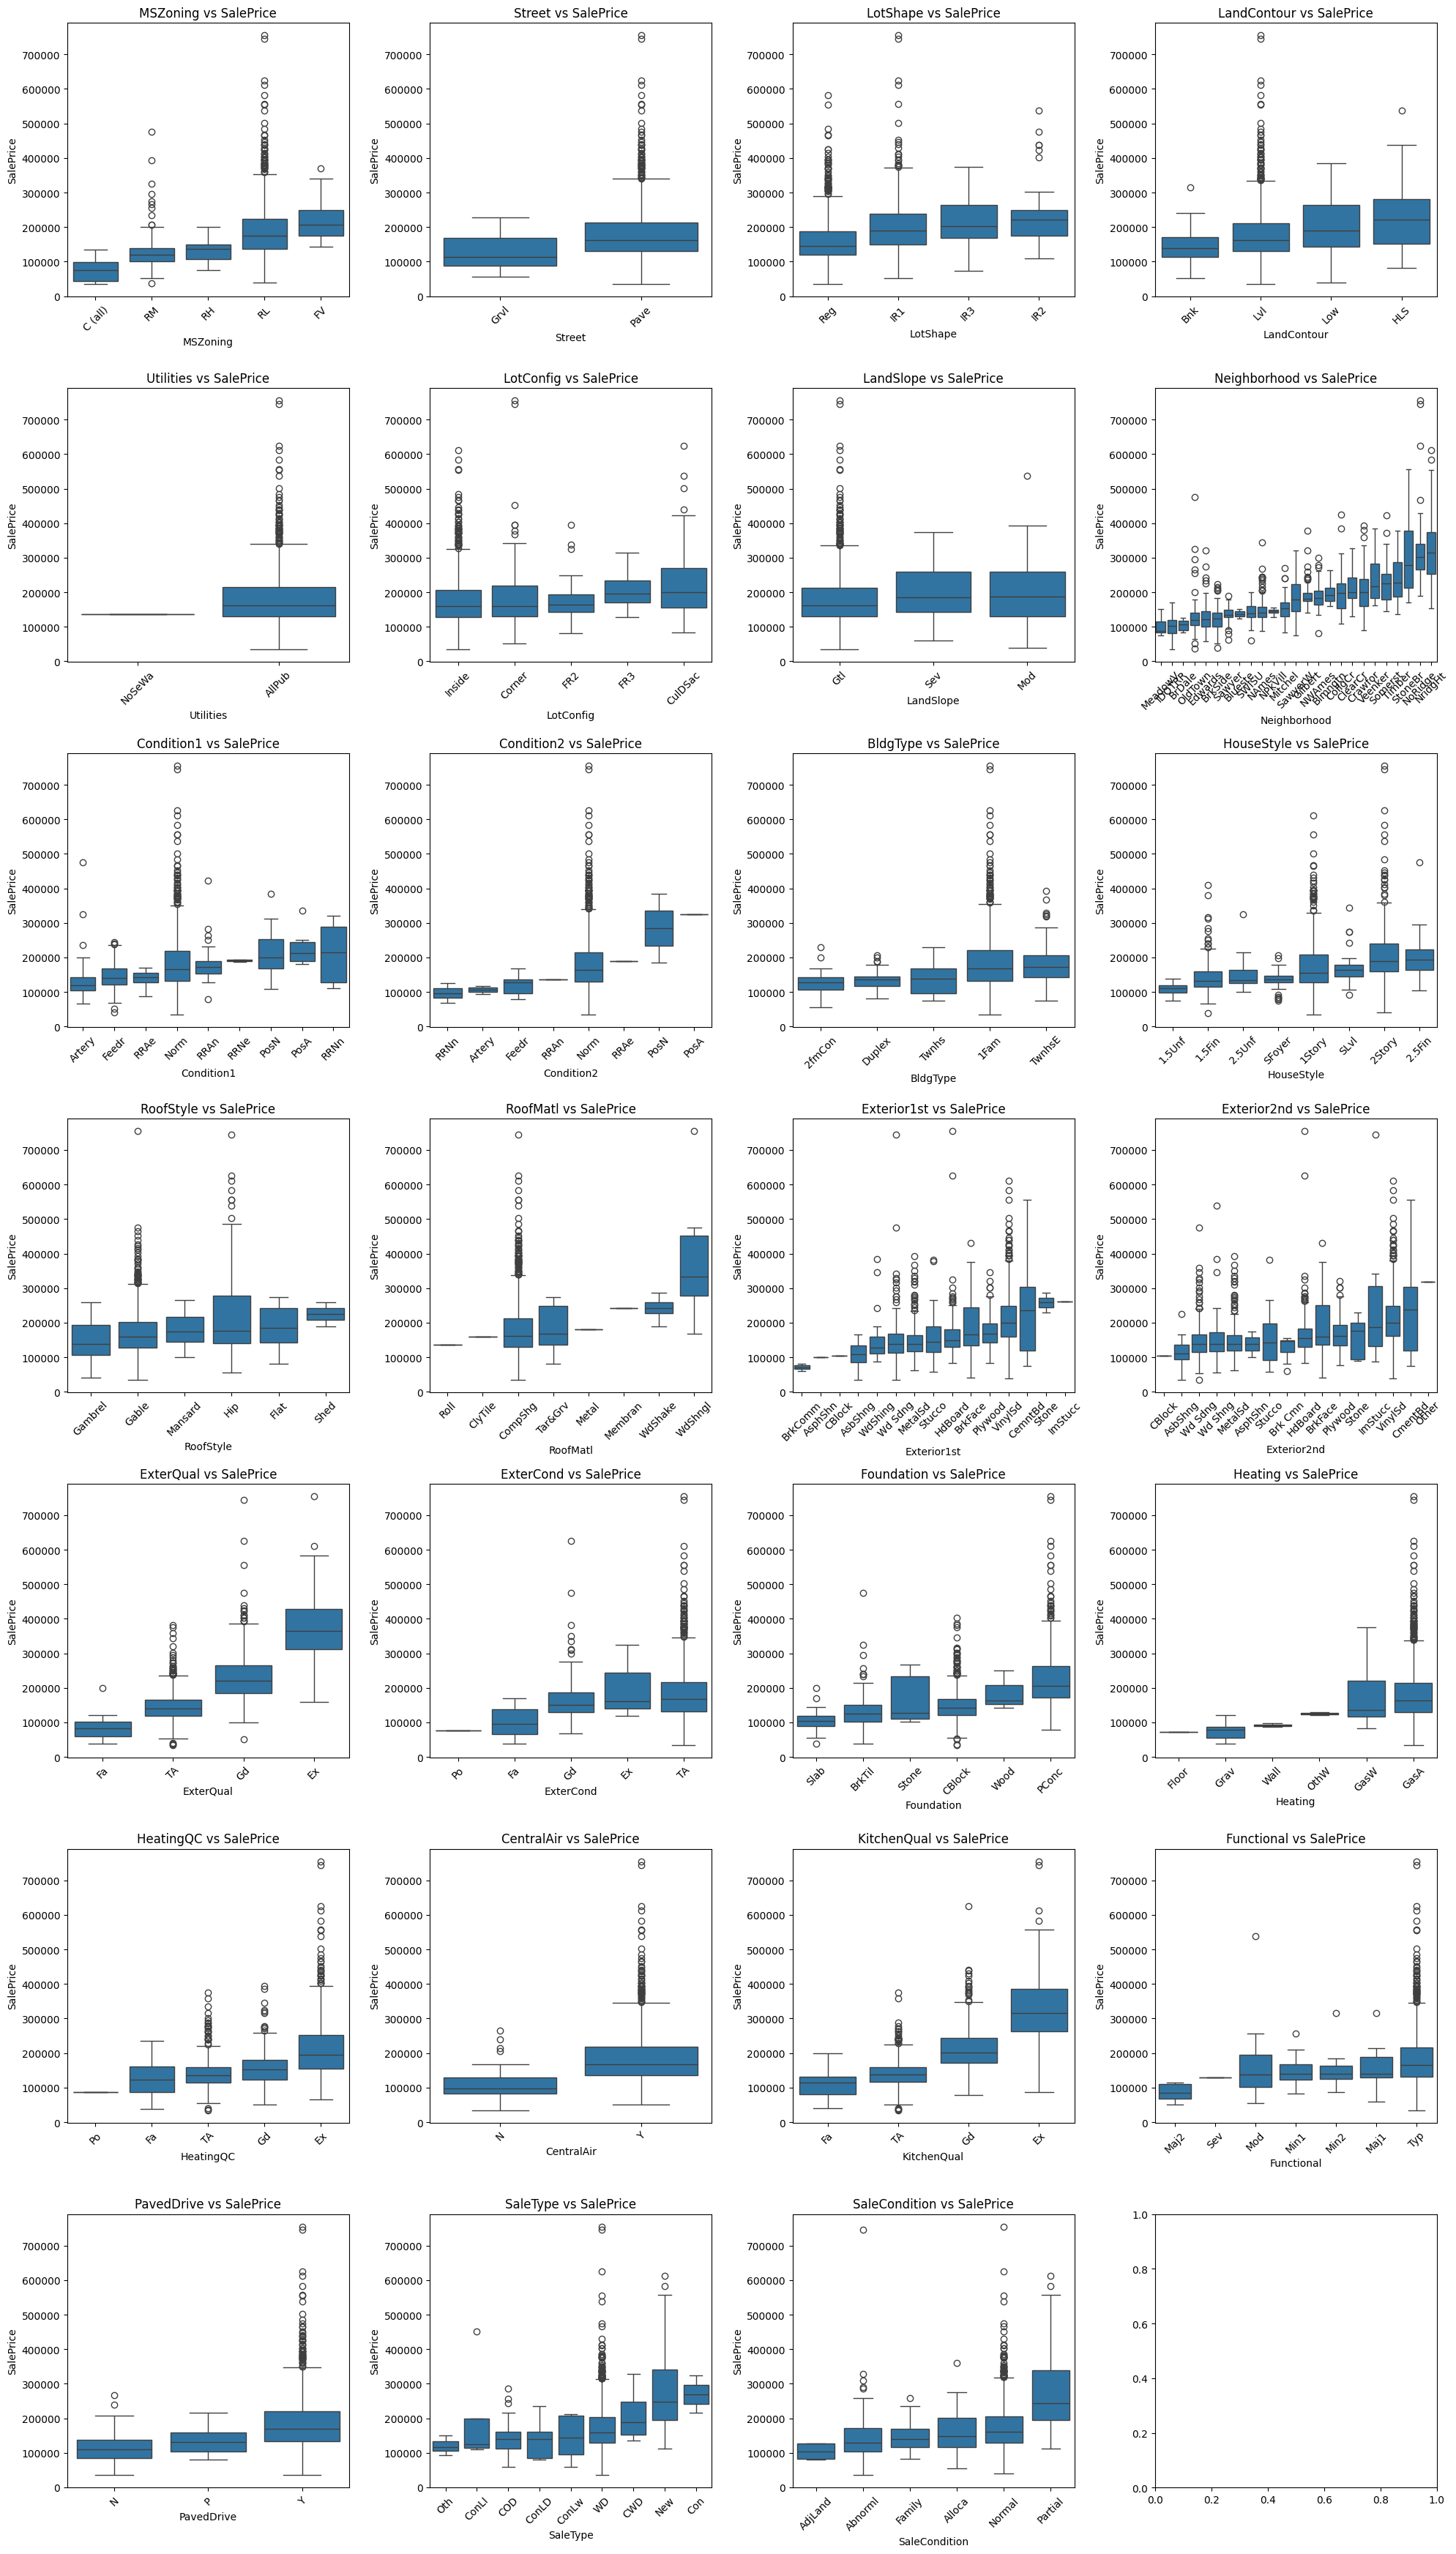

In [46]:
# Create box plots for categorical variables against SalePrice, order the plots according to increasing  median
categorical_cols = train.select_dtypes(include=['string']).columns
n_rows = (len(categorical_cols) + 3) // 4  # Calculate number of rows
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows))

for i, col in enumerate(categorical_cols):
    ax = axes[i // 4, i % 4]
    medians = train.groupby(col)['SalePrice'].median().sort_values()
    sns.boxplot(x=train[col], y=train['SalePrice'], ax=ax, order = medians.index)
    ax.set_title(f"{col} vs SalePrice")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Finalize the cleaned datasets by translating objects and strings to numeirical values
# For categorical variables, use one-hot encoding 
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)
